🧮 Assignment: K-Means Clustering using Python (Mall Customer Segmentation)

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
# -----------------------------------------------------------
# Step 1: Load Dataset
# -----------------------------------------------------------

# You can download 'Mall_Customers.csv' from Kaggle:
# https://www.kaggle.com/vjchoudhary7/customer-segmentation-tutorial-in-python

# For demonstration, create a small sample dataset if file not available
try:
    df = pd.read_csv("Mall_Customers.csv")
except FileNotFoundError:
    data = {
        'CustomerID': range(1, 11),
        'Gender': ['Male','Female','Female','Male','Female','Male','Male','Female','Female','Male'],
        'Age': [19,21,20,23,31,22,35,23,64,30],
        'Annual Income (k$)': [15,16,17,35,45,23,40,60,70,55],
        'Spending Score (1-100)': [39,81,6,77,40,76,6,94,3,73]
    }
    df = pd.DataFrame(data)

print("🔹 First 5 rows of dataset:")
print(df.head())

🔹 First 5 rows of dataset:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2  Female   21                  16                      81
2           3  Female   20                  17                       6
3           4    Male   23                  35                      77
4           5  Female   31                  45                      40


In [3]:
# -----------------------------------------------------------
# Step 2: Select Features for Clustering
# -----------------------------------------------------------

X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

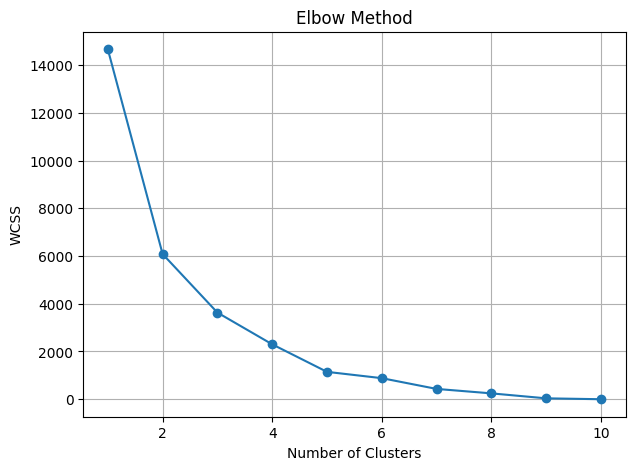

In [4]:
# -----------------------------------------------------------
# Step 3: Determine Optimal Number of Clusters (Elbow Method)
# -----------------------------------------------------------

wcss = []  # Within-cluster sum of squares
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(7,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()


In [5]:
# -----------------------------------------------------------
# Step 4: Apply K-Means Clustering
# -----------------------------------------------------------

# From the elbow method, assume optimal clusters = 5
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X)

# Add cluster column to dataset
df['Cluster'] = y_kmeans

print("\n✅ Clustered Data:")
print(df.head())



✅ Clustered Data:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2  Female   21                  16                      81   
2           3  Female   20                  17                       6   
3           4    Male   23                  35                      77   
4           5  Female   31                  45                      40   

   Cluster  
0        2  
1        0  
2        1  
3        0  
4        2  


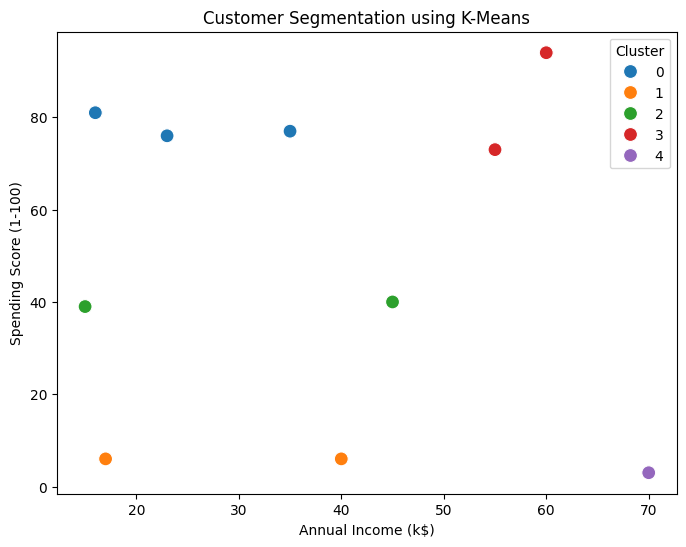

In [6]:
# -----------------------------------------------------------
# Step 5: Visualize the Clusters
# -----------------------------------------------------------

plt.figure(figsize=(8,6))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)',
                hue='Cluster', data=df, palette='tab10', s=100)
plt.title('Customer Segmentation using K-Means')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Cluster')
plt.show()

In [7]:
# -----------------------------------------------------------
# Step 6: Analyze Cluster Centers
# -----------------------------------------------------------

centers = pd.DataFrame(kmeans.cluster_centers_, columns=['Annual Income (k$)', 'Spending Score (1-100)'])
print("\n🔹 Cluster Centers:")
print(centers)


🔹 Cluster Centers:
   Annual Income (k$)  Spending Score (1-100)
0           24.666667                    78.0
1           28.500000                     6.0
2           30.000000                    39.5
3           57.500000                    83.5
4           70.000000                     3.0
